In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans





In [143]:
#Loading the RFM data
df=pd.read_csv("retail_rfm_data.csv")

In [144]:
df.head()

,customerid,recency,frequency,monetary
0,14646,1,74,280206.02
1,18102,0,60,259657.30
2,17450,8,46,194550.79
3,16446,0,2,168472.50
4,14911,1,201,143825.06


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  4339 non-null   int64  
 1   recency     4339 non-null   int64  
 2   frequency   4339 non-null   int64  
 3   monetary    4339 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.7 KB


In [146]:
#checking null values
print(df.isnull().sum())

customerid    0
recency       0
frequency     0
monetary      0
dtype: int64


In [147]:
#removing null values
df=df.dropna()

In [148]:
#Using the StandardScaler to scale the data
scaler=StandardScaler()
X=scaler.fit_transform(df[['recency','frequency','monetary']])

In [149]:
df.columns

Index(['customerid', 'recency', 'frequency', 'monetary'], dtype='object')

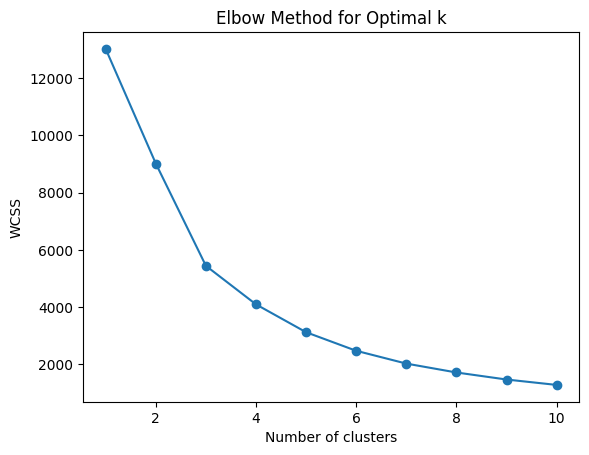

In [150]:
#within cluster sum of squares
wcss=[]
for i in range(1, 11):
    kmeans=KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

#plotting elbow curve
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()


===== K=3 Cluster Summary =====
             recency  frequency      monetary
Cluster3                                     
0           5.461538  66.500000  85904.351538
1         246.122355   1.581417    631.706219
2          40.821761   4.676999   1857.169901
===== K=4 Cluster Summary =====
             recency  frequency       monetary
Cluster4                                      
0          43.477079   3.655206    1349.382626
1           6.615385  82.692308  127338.313846
2         248.173421   1.551367     478.194731
3          15.123223  22.047393   12453.225924


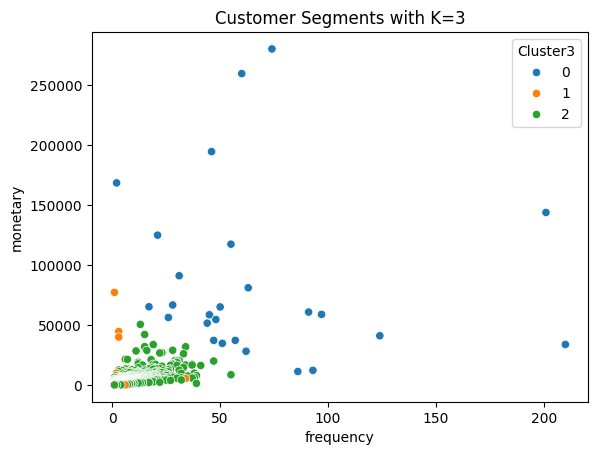

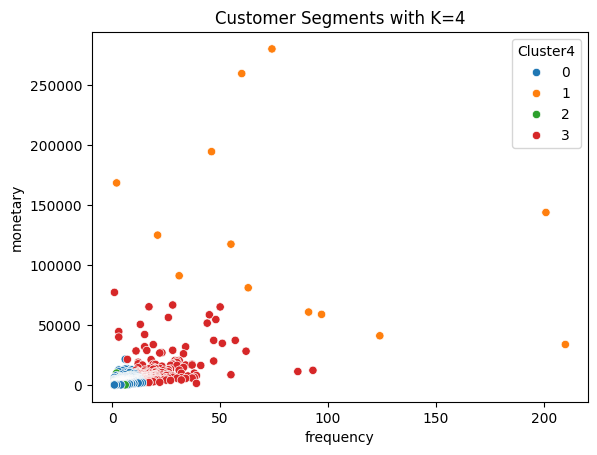

In [151]:
# K = 3
kmeans3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster3'] = kmeans3.fit_predict(X)


# K = 4
kmeans4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster4'] = kmeans4.fit_predict(X)


# Compare average RFM
print("===== K=3 Cluster Summary =====")
print(
    df.groupby('Cluster3')[['recency', 'frequency', 'monetary']]
      .mean()
)

print("===== K=4 Cluster Summary =====")
print(
    df.groupby('Cluster4')[['recency', 'frequency', 'monetary']]
      .mean()
)


# K = 3 visualization
sns.scatterplot(
    data=df,
    x='frequency',
    y='monetary',
    hue='Cluster3',
    palette='tab10'
)

plt.title("Customer Segments with K=3")
plt.show()


# K = 4 visualization
sns.scatterplot(
    data=df,
    x='frequency',
    y='monetary',
    hue='Cluster4',
    palette='tab10'
)

plt.title("Customer Segments with K=4")
plt.show()

In [152]:
# Train KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# Verify
print(df.head())

   customerid  recency  frequency   monetary  Cluster3  Cluster4  Cluster
0       14646        1         74  280206.02         0         1        1
1       18102        0         60  259657.30         0         1        1
2       17450        8         46  194550.79         0         1        1
3       16446        0          2  168472.50         0         1        1
4       14911        1        201  143825.06         0         1        1


Cluster Summary (k=4):
             recency  frequency       monetary
Cluster                                      
0         43.477079   3.655206    1349.382626
1          6.615385  82.692308  127338.313846
2        248.173421   1.551367     478.194731
3         15.123223  22.047393   12453.225924

Customer counts per cluster:
 Cluster
0    3054
2    1061
3     211
1      13
Name: count, dtype: int64


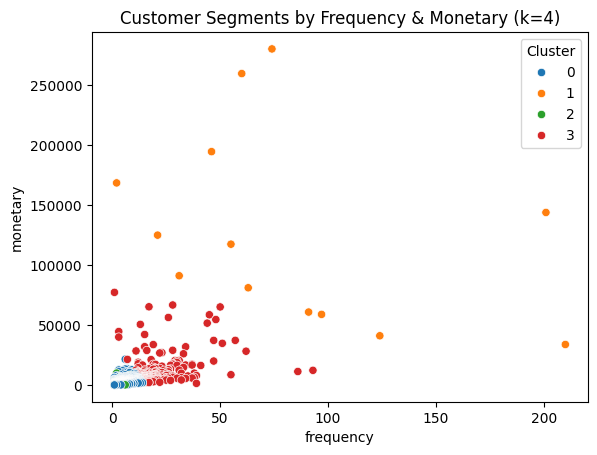

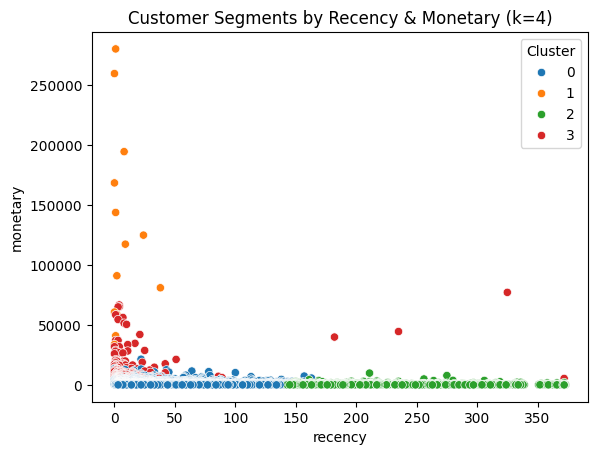

In [153]:
# Average values by cluster
summary = df.groupby('Cluster')[['recency','frequency','monetary']].mean()
print("Cluster Summary (k=4):\n", summary)

# Customer count per cluster
print("\nCustomer counts per cluster:\n", df['Cluster'].value_counts())

# Scatterplots for visualization
sns.scatterplot(data=df, x='frequency', y='monetary', hue='Cluster', palette='tab10')
plt.title("Customer Segments by Frequency & Monetary (k=4)")
plt.show()

sns.scatterplot(data=df, x='recency', y='monetary', hue='Cluster', palette='tab10')
plt.title("Customer Segments by Recency & Monetary (k=4)")
plt.show()

In [154]:
# Map cluster ID to descriptive labels
cluster_labels={
    0: "Potential Customers",
    1: "Champions",
    2: "Lost Customers",
    3: "Loyal Customers"
}

df['ClusterLabel']=df['Cluster'].map(cluster_labels)

# 
print(df[['customerid', 'recency', 'monetary', 'Cluster', 'ClusterLabel']].head())

   customerid  recency   monetary  Cluster ClusterLabel
0       14646        1  280206.02        1    Champions
1       18102        0  259657.30        1    Champions
2       17450        8  194550.79        1    Champions
3       16446        0  168472.50        1    Champions
4       14911        1  143825.06        1    Champions


In [155]:
print(
    df.groupby('Cluster4')[['recency', 'frequency', 'monetary']]
      .mean()
      .round(2)
)

          recency  frequency   monetary
Cluster4                               
0           43.48       3.66    1349.38
1            6.62      82.69  127338.31
2          248.17       1.55     478.19
3           15.12      22.05   12453.23


In [156]:

df.groupby("ClusterLabel")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
ClusterLabel,,,
Champions,6.615385,82.692308,127338.313846
Lost Customers,248.173421,1.551367,478.194731
Loyal Customers,15.123223,22.047393,12453.225924
Potential Customers,43.477079,3.655206,1349.382626


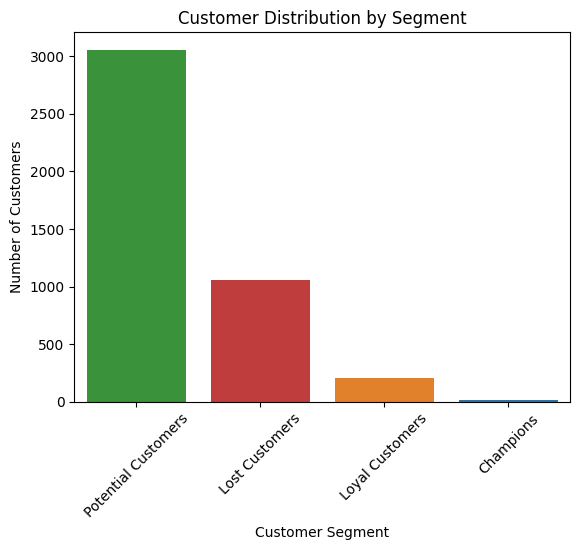

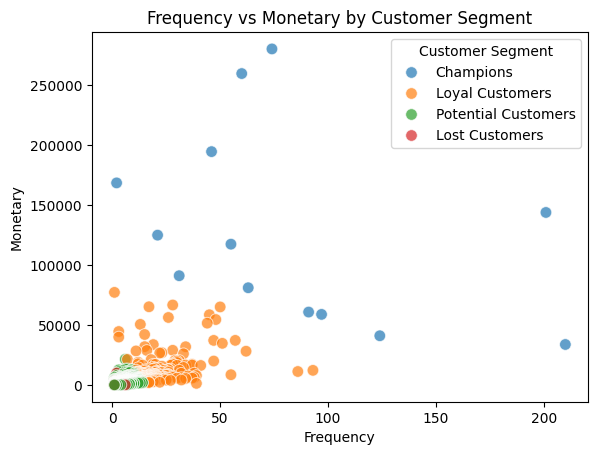

In [162]:

# Customer Distribution

sns.countplot(
    data=df,
    x='ClusterLabel',
    hue='ClusterLabel',
    order=df['ClusterLabel'].value_counts().index,
    palette='tab10',
    legend=False
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()



# Frequency vs Monetary


sns.scatterplot(
    data=df,
    x='frequency',
    y='monetary',
    hue='ClusterLabel',
    palette='tab10',
    s=70,
    alpha=0.7
)

plt.title("Frequency vs Monetary by Customer Segment")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title="Customer Segment")
plt.show()

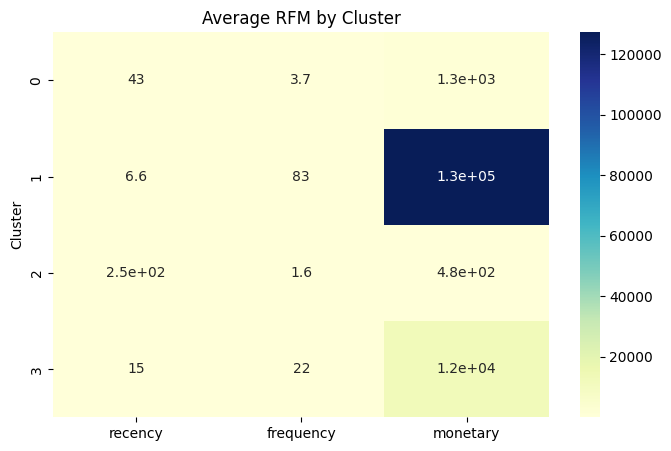

In [165]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(df.groupby('Cluster')[['recency','frequency','monetary']].mean(), annot=True, cmap="YlGnBu")
plt.title("Average RFM by Cluster")
plt.show()

In [166]:
# Saving the clusters dataset
df.to_csv("RFM_Clusters.csv", index=False)
